# Diabetes Risk Prediction from Dietary Habits and Lifestyle Factors
## UC Berkeley Data Science Capstone - Module 20

### Research Question
Can dietary habits and lifestyle factors - such as physical activity, sleep duration, 
BMI, and nutritional intake - reliably predict whether an individual is at risk for 
diabetes, and which of these modifiable behaviors are the strongest drivers of that risk?

### Data Source
NHANES 2017-2018 (CDC) - Five files covering demographics, dietary intake, 
body measures, physical activity, and diabetes diagnosis.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


## Data Loading

### Data Source
The data comes from the **NHANES 2017-2018** survey (National Health and Nutrition 
Examination Survey), published by the CDC. NHANES combines interviews, physical 
examinations, and lab tests on a nationally representative sample of Americans.

We are using 5 files from this survey, each covering a different aspect of health:

| File | Contents | Key Variables |
|------|----------|---------------|
| DEMO_J.XPT | Demographics | Age, sex, income, ethnicity |
| DIQ_J.XPT | Diabetes Questionnaire | Diabetes diagnosis (our target variable) |
| DR1TOT_J.XPT | Dietary Intake | Calories, sugar, fiber, macronutrients |
| BMX_J.XPT | Body Measures | BMI, waist circumference |
| PAQ_J.XPT | Physical Activity | Activity frequency and intensity |

All 5 files share a common column called **SEQN** (respondent ID), which we use 
to merge them into one master dataset.

In [5]:
# Load all 5 NHANES files
demo = pd.read_sas('data/DEMO_J.XPT', format='xport', encoding='utf-8')
diq = pd.read_sas('data/DIQ_J.XPT', format='xport', encoding='utf-8')
dr1 = pd.read_sas('data/DR1TOT_J.XPT', format='xport', encoding='utf-8')
bmx = pd.read_sas('data/BMX_J.XPT', format='xport', encoding='utf-8')
paq = pd.read_sas('data/PAQ_J.XPT', format='xport', encoding='utf-8')

# Merge all files on SEQN (respondent ID)
df = demo.merge(diq, on='SEQN', how='left') \
         .merge(dr1, on='SEQN', how='left') \
         .merge(bmx, on='SEQN', how='left') \
         .merge(paq, on='SEQN', how='left')

print(f"Dataset shape: {df.shape}")
print(f"Total respondents: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Dataset shape: (9254, 302)
Total respondents: 9254
Total columns: 302


## Initial Data Inspection
Before cleaning or selecting features, we take a first look at the data to understand 
its structure, column names, and data types.

In [7]:
# Look at the first 5 rows
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,...,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,...,NaN,18.0,NaN,16.2,NaN,48.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,...,NaN,18.6,NaN,15.2,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,2.0,3.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,...,NaN,36.0,NaN,32.0,NaN,101.8,NaN,110.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,1.0,2.0,60.0,300.0
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,2.0,NaN,1.0,1.0,NaN,15.0,NaN,NaN,NaN,1.0,2.0,2.0,NaN,NaN,NaN,...,NaN,38.8,NaN,27.0,NaN,79.3,NaN,94.4,NaN,2.0,NaN,NaN,2.0,NaN,NaN,1.0,5.0,45.0,2.0,NaN,NaN,1.0,2.0,30.0,240.0
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,NaN,NaN,1.0,1.0,NaN,6.0,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,...,NaN,33.8,NaN,21.5,NaN,64.1,NaN,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Check data types of each column
df.dtypes.value_counts()

float64    302
Name: count, dtype: int64

In [9]:
# Check missing values across the dataset
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})

# Only show columns that actually have missing values, sorted by worst first
missing_summary = missing_summary[missing_summary['Missing Values'] > 0].sort_values('Percentage', ascending=False)

print(f"Columns with missing values: {len(missing_summary)} out of {df.shape[1]}")
print(missing_summary.head(20))

Columns with missing values: 280 out of 302
          Missing Values  Percentage
BMIHEAD             9254  100.000000
DIQ175X             9252   99.978388
DRQSDT5             9252   99.978388
DRQSDT6             9250   99.956775
DIQ175W             9249   99.945969
DRD370PQ            9248   99.935163
DRD370JQ            9247   99.924357
DRQSDT12            9244   99.891939
DRD350JQ            9242   99.870326
DIQ175V             9240   99.848714
DRQSDT11            9238   99.827102
DIQ175R             9235   99.794683
DRD370LQ            9232   99.762265
DRQSDT8             9231   99.751459
BMIRECUM            9230   99.740653
DRQSDT10            9228   99.719040
DIQ175K             9225   99.686622
DRD370QQ            9219   99.621785
DIQ175S             9217   99.600173
DIQ175F             9216   99.589367


## Feature Selection
With 302 columns, most of which are irrelevant or mostly empty, we narrow the dataset 
down to only the variables relevant to our research question about dietary habits, 
lifestyle, and diabetes risk

In [10]:
# Select only the columns relevant to our research question
cols = [
    'SEQN',       # Respondent ID
    'RIDAGEYR',   # Age
    'RIAGENDR',   # Gender
    'RIDRETH3',   # Ethnicity
    'INDFMPIR',   # Income to poverty ratio
    'DIQ010',     # Diabetes diagnosis (TARGET VARIABLE)
    'BMXBMI',     # BMI
    'BMXWAIST',   # Waist circumference
    'DR1TKCAL',   # Total calories
    'DR1TCARB',   # Carbohydrates
    'DR1TTFAT',   # Total fat
    'DR1TPROT',   # Protein
    'DR1TSUGR',   # Total sugar
    'DR1TFIBE',   # Fiber
    'PAQ605',     # Vigorous physical activity (yes/no)
    'PAQ620',     # Moderate physical activity (yes/no)
    'PAD660',     # Minutes of vigorous activity per day
    'PAD675',     # Minutes of moderate activity per day
]

df = df[cols]

print(f"Reduced dataset shape: {df.shape}")
df.head()

Reduced dataset shape: (9254, 18)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,INDFMPIR,DIQ010,BMXBMI,BMXWAIST,DR1TKCAL,DR1TCARB,DR1TTFAT,DR1TPROT,DR1TSUGR,DR1TFIBE,PAQ605,PAQ620,PAD660,PAD675
0,93703.0,2.0,2.0,6.0,5.00,2.0,17.5,48.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,2.0,1.0,3.0,5.00,2.0,15.7,50.0,1230.0,160.46,43.24,51.58,76.97,5.9,NaN,NaN,NaN,NaN
2,93705.0,66.0,2.0,4.0,0.82,2.0,31.7,101.8,1202.0,157.45,56.98,20.01,91.55,8.4,2.0,2.0,NaN,60.0
3,93706.0,18.0,1.0,6.0,NaN,2.0,21.5,79.3,1987.0,89.82,137.39,94.19,14.73,7.1,2.0,2.0,NaN,30.0
4,93707.0,13.0,1.0,7.0,1.88,2.0,18.1,64.1,1775.0,188.15,89.18,59.48,84.22,10.9,NaN,NaN,NaN,NaN


In [14]:
# Reload all 5 files and re-merge fresh
demo = pd.read_sas('data/DEMO_J.XPT', format='xport', encoding='utf-8')
diq = pd.read_sas('data/DIQ_J.XPT', format='xport', encoding='utf-8')
dr1 = pd.read_sas('data/DR1TOT_J.XPT', format='xport', encoding='utf-8')
bmx = pd.read_sas('data/BMX_J.XPT', format='xport', encoding='utf-8')
paq = pd.read_sas('data/PAQ_J.XPT', format='xport', encoding='utf-8')

# Merge all on SEQN
df = demo.merge(diq, on='SEQN', how='left') \
         .merge(dr1, on='SEQN', how='left') \
         .merge(bmx, on='SEQN', how='left') \
         .merge(paq, on='SEQN', how='left')

# Now select all our columns
cols = [
    'SEQN',
    'RIDAGEYR', 'RIAGENDR', 'RIDRETH3',
    'DMDEDUC2', 'DMDMARTL', 'INDFMPIR',
    'DIQ010',
    'DR1TKCAL', 'DR1TPROT', 'DR1TCARB',
    'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT',
    'DR1TSFAT', 'DR1TSODI', 'DR1TALCO', 'DR1TCAFF',
    'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT',
    'PAQ605', 'PAQ620', 'PAQ635', 'PAQ650',
    'PAQ665', 'PAD660', 'PAD675', 'PAD680',
]

available = [c for c in cols if c in df.columns]
missing_cols = [c for c in cols if c not in df.columns]

print(f"Columns found: {len(available)}")
print(f"Columns NOT found: {missing_cols}")

df = df[available]
print(f"\nFinal dataset shape: {df.shape}")

Columns found: 30
Columns NOT found: []

Final dataset shape: (9254, 30)


In [15]:
# Rename columns to human-readable names
df = df.rename(columns={
    # Demographics
    'RIDAGEYR': 'age',
    'RIAGENDR': 'gender',
    'RIDRETH3': 'ethnicity',
    'DMDEDUC2': 'education',
    'DMDMARTL': 'marital_status',
    'INDFMPIR': 'income_poverty_ratio',

    # Target variable
    'DIQ010':   'diabetes',

    # Dietary intake
    'DR1TKCAL': 'calories',
    'DR1TPROT': 'protein_g',
    'DR1TCARB': 'carbs_g',
    'DR1TSUGR': 'sugar_g',
    'DR1TFIBE': 'fiber_g',
    'DR1TTFAT': 'fat_g',
    'DR1TSFAT': 'saturated_fat_g',
    'DR1TSODI': 'sodium_mg',
    'DR1TALCO': 'alcohol_g',
    'DR1TCAFF': 'caffeine_mg',

    # Body measures
    'BMXBMI':   'bmi',
    'BMXWAIST': 'waist_cm',
    'BMXWT':    'weight_kg',
    'BMXHT':    'height_cm',

    # Physical activity
    'PAQ605':   'vigorous_work_activity',
    'PAQ620':   'moderate_work_activity',
    'PAQ635':   'walks_bikes_transport',
    'PAQ650':   'vigorous_recreational_activity',
    'PAQ665':   'moderate_recreational_activity',
    'PAD660':   'vigorous_activity_min_per_day',
    'PAD675':   'moderate_activity_min_per_day',
    'PAD680':   'sedentary_min_per_day',
})

print("Columns renamed successfully!")
print(df.columns.tolist())

Columns renamed successfully!
['SEQN', 'age', 'gender', 'ethnicity', 'education', 'marital_status', 'income_poverty_ratio', 'diabetes', 'calories', 'protein_g', 'carbs_g', 'sugar_g', 'fiber_g', 'fat_g', 'saturated_fat_g', 'sodium_mg', 'alcohol_g', 'caffeine_mg', 'bmi', 'waist_cm', 'weight_kg', 'height_cm', 'vigorous_work_activity', 'moderate_work_activity', 'walks_bikes_transport', 'vigorous_recreational_activity', 'moderate_recreational_activity', 'vigorous_activity_min_per_day', 'moderate_activity_min_per_day', 'sedentary_min_per_day']


In [16]:
# Quick look at the first 5 rows
df.head()

,SEQN,age,gender,ethnicity,education,marital_status,income_poverty_ratio,diabetes,calories,protein_g,carbs_g,sugar_g,fiber_g,fat_g,saturated_fat_g,sodium_mg,alcohol_g,caffeine_mg,bmi,waist_cm,weight_kg,height_cm,vigorous_work_activity,moderate_work_activity,walks_bikes_transport,vigorous_recreational_activity,moderate_recreational_activity,vigorous_activity_min_per_day,moderate_activity_min_per_day,sedentary_min_per_day
0,93703.0,2.0,2.0,6.0,NaN,NaN,5.00,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.5,48.2,13.7,88.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,2.0,1.0,3.0,NaN,NaN,5.00,2.0,1230.0,51.58,160.46,76.97,5.9,43.24,11.372,2198.0,5.397605e-79,8.000000e+00,15.7,50.0,13.9,94.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,66.0,2.0,4.0,2.0,3.0,0.82,2.0,1202.0,20.01,157.45,91.55,8.4,56.98,16.435,3574.0,5.397605e-79,3.610000e+02,31.7,101.8,79.5,158.3,2.0,2.0,2.0,2.0,1.0,NaN,60.0,300.0
3,93706.0,18.0,1.0,6.0,NaN,NaN,NaN,2.0,1987.0,94.19,89.82,14.73,7.1,137.39,35.169,3657.0,5.397605e-79,5.397605e-79,21.5,79.3,66.3,175.7,2.0,2.0,1.0,2.0,1.0,NaN,30.0,240.0
4,93707.0,13.0,1.0,7.0,NaN,NaN,1.88,2.0,1775.0,59.48,188.15,84.22,10.9,89.18,33.252,2450.0,5.397605e-79,2.100000e+01,18.1,64.1,45.4,158.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Basic statistics for every column
df.describe()

,SEQN,age,gender,ethnicity,education,marital_status,income_poverty_ratio,diabetes,calories,protein_g,carbs_g,sugar_g,fiber_g,fat_g,saturated_fat_g,sodium_mg,alcohol_g,caffeine_mg,bmi,waist_cm,weight_kg,height_cm,vigorous_work_activity,moderate_work_activity,walks_bikes_transport,vigorous_recreational_activity,moderate_recreational_activity,vigorous_activity_min_per_day,moderate_activity_min_per_day,sedentary_min_per_day
count,9254.000000,9.254000e+03,9254.000000,9254.000000,5569.000000,5569.000000,8.023000e+03,8897.000000,7.484000e+03,7.484000e+03,7.484000e+03,7.484000e+03,7.484000e+03,7.484000e+03,7.484000e+03,7.484000e+03,7.484000e+03,7.484000e+03,8005.000000,7601.000000,8580.000000,8016.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,1431.000000,2301.000000,5.846000e+03
mean,98329.500000,3.433423e+01,1.507564,3.497190,3.525768,2.688813,2.375490e+00,1.923457,1.985156e+03,7.274174e+01,2.400289e+02,1.057063e+02,1.533315e+01,7.976571e+01,2.626001e+01,3.167725e+03,5.848530e+00,1.002503e+02,26.577502,89.928851,65.138508,156.593401,1.769980,1.589481,1.754269,1.755123,1.605874,83.176101,68.284659,3.895582e+02
std,2671.544029,2.550028e+01,0.499970,1.700961,1.240231,3.073212,1.600291e+00,0.370457,9.886384e+02,4.154791e+01,1.246596e+02,7.251687e+01,1.029534e+01,4.729587e+01,1.696917e+01,1.867412e+03,2.208234e+01,1.843162e+02,8.260724,22.805093,32.890754,22.257858,0.484281,0.538384,0.430556,0.430051,0.488704,267.651485,215.166165,7.718131e+02
min,93703.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,12.300000,40.000000,3.200000,78.300000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,10.000000,5.397605e-79
25%,96016.250000,1.100000e+01,1.000000,3.000000,3.000000,1.000000,1.040000e+00,2.000000,1.307000e+03,4.480000e+01,1.566825e+02,5.812750e+01,8.300000e+00,4.685000e+01,1.470050e+01,1.920500e+03,5.397605e-79,1.000000e+00,20.400000,73.900000,43.100000,151.400000,2.000000,1.000000,2.000000,2.000000,1.000000,42.500000,30.000000,1.800000e+02
50%,98329.500000,3.100000e+01,2.000000,3.000000,4.000000,2.000000,1.920000e+00,2.000000,1.811000e+03,6.513500e+01,2.190450e+02,9.075500e+01,1.310000e+01,7.042000e+01,2.274400e+01,2.816000e+03,5.397605e-79,3.500000e+01,25.800000,91.200000,67.750000,161.900000,2.000000,2.000000,2.000000,2.000000,2.000000,60.000000,60.000000,3.000000e+02
75%,100642.750000,5.800000e+01,2.000000,4.000000,4.000000,5.000000,3.690000e+00,2.000000,2.470000e+03,9.178250e+01,2.991000e+02,1.348750e+02,1.972500e+01,1.015025e+02,3.397975e+01,4.026750e+03,5.397605e-79,1.430000e+02,31.300000,105.300000,85.600000,171.200000,2.000000,2.000000,2.000000,2.000000,2.000000,120.000000,60.000000,4.800000e+02
max,102956.000000,8.000000e+01,2.000000,7.000000,9.000000,77.000000,5.000000e+00,9.000000,1.250100e+04,5.452000e+02,1.476760e+03,9.311600e+02,1.078000e+02,5.679600e+02,1.958520e+02,2.594900e+04,4.068000e+02,4.320000e+03,86.200000,169.500000,242.600000,197.700000,9.000000,9.000000,2.000000,2.000000,2.000000,9999.000000,9999.000000,9.999000e+03


In [18]:
# Filter to adults only (18+)
# Children don't have education, marital status, or dietary data
df = df[df['age'] >= 18]

print(f"Dataset shape after filtering to adults: {df.shape}")
print(f"\nDiabetes value counts (before cleaning):")
print(df['diabetes'].value_counts().sort_index())

Dataset shape after filtering to adults: (5856, 30)

Diabetes value counts (before cleaning):
diabetes
1.0     878
2.0    4800
3.0     174
9.0       4
Name: count, dtype: int64


## Data Cleaning

### Target Variable
NHANES codes the diabetes diagnosis variable (DIQ010) as follows:
- 1 = Yes, diabetic
- 2 = No
- 3 = Borderline / prediabetic
- 9 = Don't know (removed)

We combine diabetic (1) and prediabetic (3) into a single positive class (1), 
since prediabetes represents genuine metabolic risk with similar behavioral drivers.
Code 9 (Don't know) is removed as it provides no useful information.

In [19]:
# Remove "don't know" responses
df = df[df['diabetes'] != 9.0]

# Combine prediabetic (3) with diabetic (1)
df['diabetes'] = df['diabetes'].replace(3.0, 1.0)

# Recode: 1 = diabetic/prediabetic, 0 = not diabetic
df['diabetes'] = df['diabetes'].replace(2.0, 0.0)

print("Diabetes value counts after cleaning:")
print(df['diabetes'].value_counts().sort_index())
print(f"\nDiabetes rate: {df['diabetes'].mean()*100:.1f}%")
print(f"Dataset shape: {df.shape}")

Diabetes value counts after cleaning:
diabetes
0.0    4800
1.0    1052
Name: count, dtype: int64

Diabetes rate: 18.0%
Dataset shape: (5852, 30)


In [20]:
# Clean up coded values in other columns

# Gender: 1=Male, 2=Female → recode to 0=Male, 1=Female
df['gender'] = df['gender'].replace({1.0: 0.0, 2.0: 1.0})

# Physical activity yes/no columns: 1=Yes, 2=No → recode to 1=Yes, 0=No
activity_cols = [
    'vigorous_work_activity', 'moderate_work_activity',
    'walks_bikes_transport', 'vigorous_recreational_activity',
    'moderate_recreational_activity'
]
for col in activity_cols:
    df[col] = df[col].replace({1.0: 1.0, 2.0: 0.0, 7.0: np.nan, 9.0: np.nan})

# Education: 7=Refused, 9=Don't know → NaN
df['education'] = df['education'].replace({7.0: np.nan, 9.0: np.nan})

# Marital status: 77=Refused, 99=Don't know → NaN
df['marital_status'] = df['marital_status'].replace({77.0: np.nan, 99.0: np.nan})

print("Coded values cleaned!")
print(f"\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

Coded values cleaned!

Missing values per column:
vigorous_activity_min_per_day     4422
moderate_activity_min_per_day     3551
sodium_mg                          870
carbs_g                            870
caffeine_mg                        870
alcohol_g                          870
saturated_fat_g                    870
fat_g                              870
fiber_g                            870
sugar_g                            870
protein_g                          870
calories                           870
income_poverty_ratio               832
waist_cm                           671
bmi                                422
height_cm                          412
weight_kg                          412
education                          299
marital_status                     293
sedentary_min_per_day               10
vigorous_work_activity               6
moderate_work_activity               5
age                                  0
diabetes                             0
walks_bikes_tr

In [21]:
# Fix activity minutes — missing means zero (person said they don't do that activity)
df['vigorous_activity_min_per_day'] = df['vigorous_activity_min_per_day'].fillna(0)
df['moderate_activity_min_per_day'] = df['moderate_activity_min_per_day'].fillna(0)

# Drop rows where dietary data is completely missing (870 rows)
# Diet is central to our research question so we can't impute these
dietary_cols = ['calories', 'protein_g', 'carbs_g', 'sugar_g', 
                'fiber_g', 'fat_g', 'saturated_fat_g', 'sodium_mg',
                'alcohol_g', 'caffeine_mg']
df = df.dropna(subset=dietary_cols)

# Impute body measures with median
body_cols = ['bmi', 'waist_cm', 'weight_kg', 'height_cm']
for col in body_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute income with median
df['income_poverty_ratio'] = df['income_poverty_ratio'].fillna(df['income_poverty_ratio'].median())

# Impute education and marital status with mode (most common value)
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['marital_status'] = df['marital_status'].fillna(df['marital_status'].mode()[0])

# Drop remaining rows with missing values (sedentary, work activity — very few)
df = df.dropna()

print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nMissing values remaining:")
print(df.isnull().sum().sum())
print(f"\nDiabetes rate after cleaning: {df['diabetes'].mean()*100:.1f}%")

Dataset shape after cleaning: (4966, 30)

Missing values remaining:
0

Diabetes rate after cleaning: 18.0%


### Outlier Detection
We check for extreme values in continuous variables that could distort our model.
We use the IQR (Interquartile Range) method to identify outliers.

In [22]:
# Check for outliers in continuous columns using IQR method
continuous_cols = [
    'age', 'bmi', 'waist_cm', 'calories', 'sugar_g', 
    'fiber_g', 'fat_g', 'sodium_mg', 'vigorous_activity_min_per_day',
    'moderate_activity_min_per_day', 'sedentary_min_per_day'
]

print("Outlier summary:")
print(f"{'Column':<35} {'Min':>10} {'Max':>10} {'Outliers':>10}")
print("-" * 70)

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col:<35} {df[col].min():>10.1f} {df[col].max():>10.1f} {outliers:>10}")

Outlier summary:
Column                                     Min        Max   Outliers
----------------------------------------------------------------------
age                                       18.0       80.0          0
bmi                                       14.8       84.4        144
waist_cm                                  56.4      169.5         80
calories                                   0.0    12501.0        135
sugar_g                                    0.0      931.2        190
fiber_g                                    0.0      107.8        194
fat_g                                      0.0      568.0        158
sodium_mg                                  0.0    25949.0        176
vigorous_activity_min_per_day              0.0     9999.0       1212
moderate_activity_min_per_day              0.0     9999.0        435
sedentary_min_per_day                      0.0     9999.0         68


In [23]:
# Replace 9999 (Don't know) codes in activity columns with 0
activity_min_cols = [
    'vigorous_activity_min_per_day',
    'moderate_activity_min_per_day', 
    'sedentary_min_per_day'
]

for col in activity_min_cols:
    df[col] = df[col].replace(9999.0, np.nan).fillna(0)

# Cap extreme dietary outliers at 99th percentile
# This keeps the data realistic without deleting rows
dietary_continuous = ['calories', 'sugar_g', 'fiber_g', 'fat_g', 'sodium_mg']

for col in dietary_continuous:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

print("Outliers handled!")
print(f"\nNew max values after capping:")
for col in dietary_continuous:
    print(f"  {col}: {df[col].max():.1f}")

print(f"\nNew max activity values:")
for col in activity_min_cols:
    print(f"  {col}: {df[col].max():.1f}")

Outliers handled!

New max values after capping:
  calories: 5491.7
  sugar_g: 389.3
  fiber_g: 53.0
  fat_g: 252.1
  sodium_mg: 9721.2

New max activity values:
  vigorous_activity_min_per_day: 480.0
  moderate_activity_min_per_day: 540.0
  sedentary_min_per_day: 1320.0


In [24]:
# Final summary of clean dataset
print("=== CLEAN DATASET SUMMARY ===")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"\nDiabetes breakdown:")
print(f"  Not diabetic: {(df['diabetes']==0).sum()} ({(df['diabetes']==0).mean()*100:.1f}%)")
print(f"  Diabetic/Prediabetic: {(df['diabetes']==1).sum()} ({(df['diabetes']==1).mean()*100:.1f}%)")
print(f"\nAge range: {df['age'].min():.0f} to {df['age'].max():.0f} years")
print(f"BMI range: {df['bmi'].min():.1f} to {df['bmi'].max():.1f}")
print(f"Average calories: {df['calories'].mean():.0f} per day")

=== CLEAN DATASET SUMMARY ===
Total rows: 4966
Total columns: 30

Diabetes breakdown:
  Not diabetic: 4074 (82.0%)
  Diabetic/Prediabetic: 892 (18.0%)

Age range: 18 to 80 years
BMI range: 14.8 to 84.4
Average calories: 2097 per day


## Exploratory Data Analysis (EDA)
We now explore the relationships between our features and diabetes status
through visualizations, looking for patterns that inform our model.

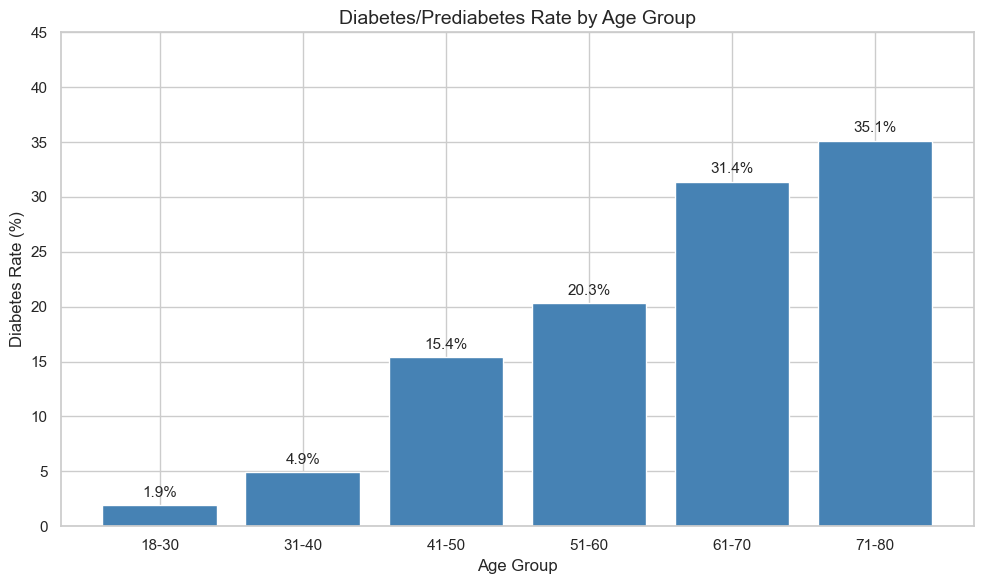

In [26]:
# Create age groups
df['age_group'] = pd.cut(df['age'], 
                          bins=[18, 30, 40, 50, 60, 70, 80],
                          labels=['18-30', '31-40', '41-50', '51-60', '61-70', '71-80'])

# Calculate diabetes rate per age group
age_diabetes = df.groupby('age_group', observed=True)['diabetes'].mean() * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(age_diabetes.index, age_diabetes.values, color='steelblue', edgecolor='white')

# Add percentage labels on top of each bar
for bar, val in zip(bars, age_diabetes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Diabetes/Prediabetes Rate by Age Group', fontsize=14)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Diabetes Rate (%)', fontsize=12)
ax.set_ylim(0, 45)
plt.tight_layout()
plt.show()

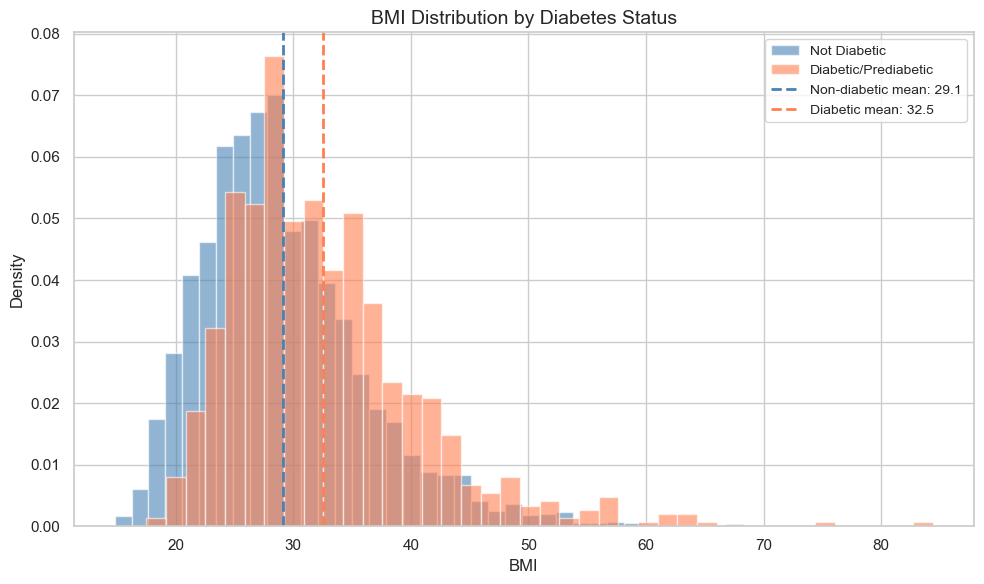

In [27]:
# BMI distribution by diabetes status
fig, ax = plt.subplots(figsize=(10, 6))

# Plot two overlapping distributions
ax.hist(df[df['diabetes']==0]['bmi'], bins=40, alpha=0.6, 
        color='steelblue', label='Not Diabetic', density=True)
ax.hist(df[df['diabetes']==1]['bmi'], bins=40, alpha=0.6, 
        color='coral', label='Diabetic/Prediabetic', density=True)

# Add vertical lines for group means
ax.axvline(df[df['diabetes']==0]['bmi'].mean(), 
           color='steelblue', linestyle='--', linewidth=2,
           label=f"Non-diabetic mean: {df[df['diabetes']==0]['bmi'].mean():.1f}")
ax.axvline(df[df['diabetes']==1]['bmi'].mean(), 
           color='coral', linestyle='--', linewidth=2,
           label=f"Diabetic mean: {df[df['diabetes']==1]['bmi'].mean():.1f}")

ax.set_title('BMI Distribution by Diabetes Status', fontsize=14)
ax.set_xlabel('BMI', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

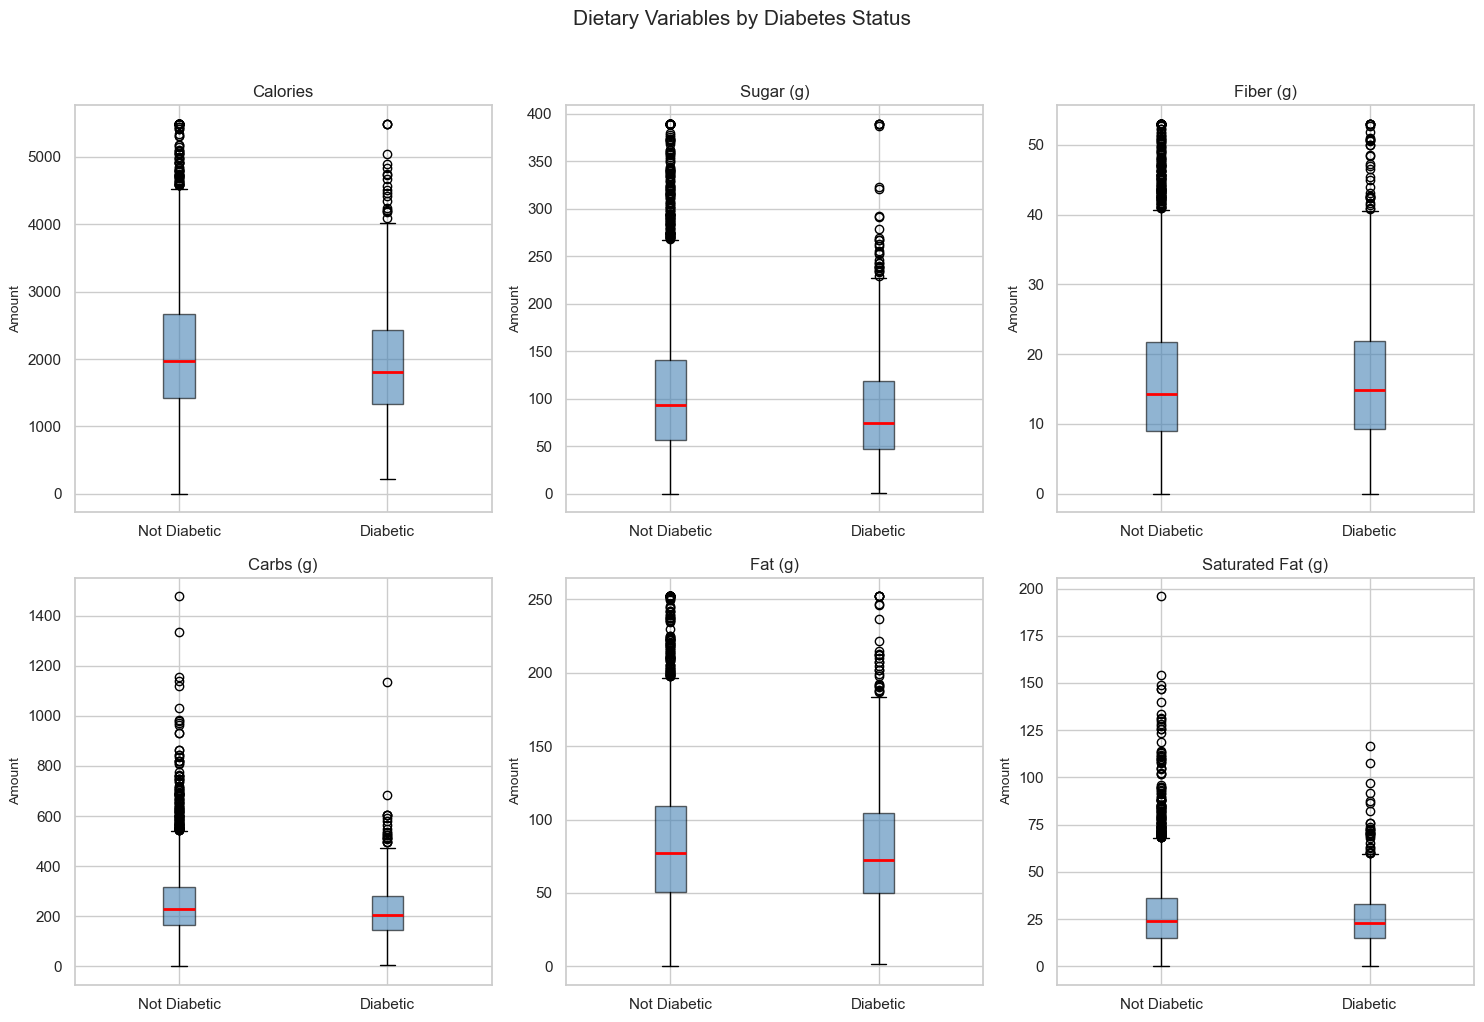

In [30]:
# Compare key dietary variables between diabetic and non-diabetic groups
dietary_vars = ['calories', 'sugar_g', 'fiber_g', 'carbs_g', 'fat_g', 'saturated_fat_g']
labels = ['Calories', 'Sugar (g)', 'Fiber (g)', 'Carbs (g)', 'Fat (g)', 'Saturated Fat (g)']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (var, label) in enumerate(zip(dietary_vars, labels)):
    non_diabetic = df[df['diabetes']==0][var]
    diabetic = df[df['diabetes']==1][var]
    
    axes[i].boxplot([non_diabetic, diabetic], 
                    tick_labels=['Not Diabetic', 'Diabetic'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    
    axes[i].set_title(label, fontsize=12)
    axes[i].set_ylabel('Amount', fontsize=10)

fig.suptitle('Dietary Variables by Diabetes Status', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### Key Finding — Dietary Variables
Dietary variables alone show surprisingly little difference between diabetic 
and non-diabetic groups. This suggests that diabetes risk is not driven by 
diet in isolation, but rather by the interaction between dietary habits, 
physical activity, BMI, and age. It is also possible that some diabetic 
respondents had already modified their diet following diagnosis, which would 
compress the differences between groups.

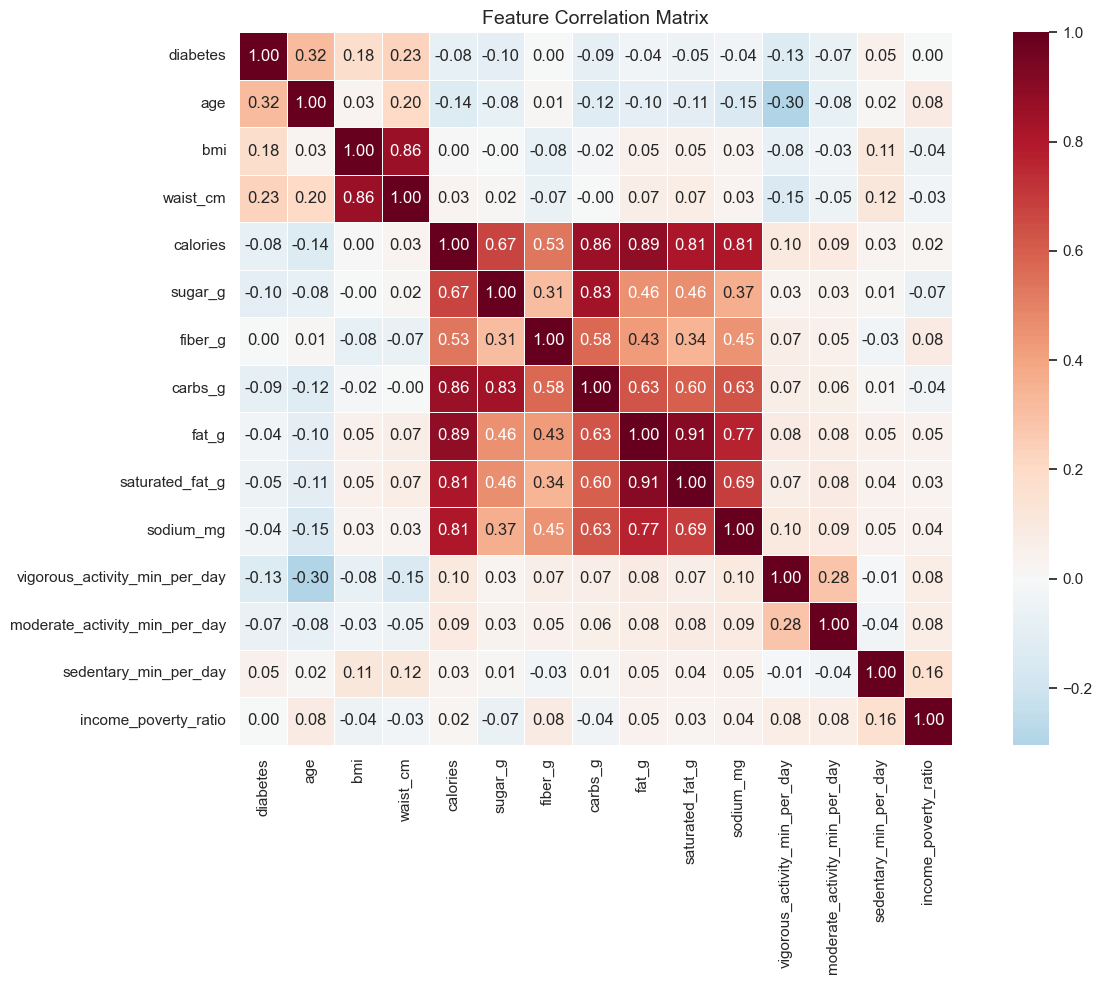

In [31]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

# Calculate correlations with diabetes
corr_matrix = df[[
    'diabetes', 'age', 'bmi', 'waist_cm',
    'calories', 'sugar_g', 'fiber_g', 'carbs_g',
    'fat_g', 'saturated_fat_g', 'sodium_mg',
    'vigorous_activity_min_per_day',
    'moderate_activity_min_per_day',
    'sedentary_min_per_day',
    'income_poverty_ratio'
]].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## Key Finding — Correlation Analysis
The strongest predictors of diabetes in this dataset are:
1. Age (0.32) — the single strongest predictor
2. Waist circumference (0.23) — a proxy for abdominal obesity
3. BMI (0.18) — overall body weight
4. Vigorous physical activity (-0.13) — protective factor

Dietary variables show weak negative correlations with diabetes, 
consistent with the boxplot findings above. BMI and waist circumference 
are highly correlated (0.86), suggesting multicollinearity — we will 
address this during modeling.

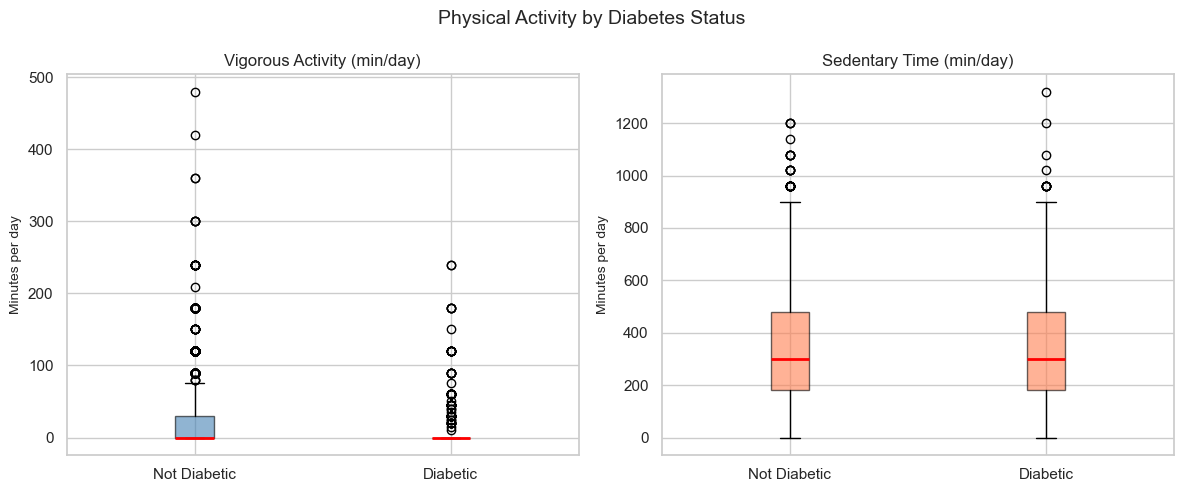

In [33]:
# Physical activity comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vigorous activity minutes
axes[0].boxplot([
    df[df['diabetes']==0]['vigorous_activity_min_per_day'],
    df[df['diabetes']==1]['vigorous_activity_min_per_day']],
    tick_labels=['Not Diabetic', 'Diabetic'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Vigorous Activity (min/day)', fontsize=12)
axes[0].set_ylabel('Minutes per day', fontsize=10)

# Sedentary minutes
axes[1].boxplot([
    df[df['diabetes']==0]['sedentary_min_per_day'],
    df[df['diabetes']==1]['sedentary_min_per_day']],
    tick_labels=['Not Diabetic', 'Diabetic'],
    patch_artist=True,
    boxprops=dict(facecolor='coral', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Sedentary Time (min/day)', fontsize=12)
axes[1].set_ylabel('Minutes per day', fontsize=10)

fig.suptitle('Physical Activity by Diabetes Status', fontsize=14)
plt.tight_layout()
plt.show()

### Key Finding — Physical Activity
Most participants report little to no vigorous physical activity regardless 
of diabetes status, making this variable difficult to use as a strong 
predictor on its own. Sedentary time is similarly distributed between 
groups. This suggests physical activity patterns in this dataset are not 
strongly differentiated by diabetes status, though the correlation matrix 
confirmed a modest protective effect of vigorous activity (-0.13).

## Baseline Model - Logistic Regression

We build a baseline logistic regression model to predict diabetes status.
Logistic regression is chosen as the baseline because it is interpretable,
computationally efficient, and produces probability scores that can be
evaluated with AUC-ROC.

### Why AUC-ROC as our primary metric?
The dataset has class imbalance (82% non-diabetic, 18% diabetic). Accuracy 
alone would be misleading — a model predicting "not diabetic" for everyone 
would score 82% accuracy but have zero predictive value. AUC-ROC measures 
how well the model separates the two classes regardless of their sizes.
Recall is also prioritized because a false negative (missing a diabetic 
person) carries a higher real-world cost than a false positive.

In [34]:
# Step 1 — Prepare features and target variable
# Drop SEQN (ID column) and age_group (derived from age, not a real feature)
features = df.drop(columns=['SEQN', 'diabetes', 'age_group'])
target = df['diabetes']

print(f"Features shape: {features.shape}")
print(f"Target shape: {target.shape}")
print(f"\nFeature columns:")
for col in features.columns:
    print(f"  {col}")

Features shape: (4966, 28)
Target shape: (4966,)

Feature columns:
  age
  gender
  ethnicity
  education
  marital_status
  income_poverty_ratio
  calories
  protein_g
  carbs_g
  sugar_g
  fiber_g
  fat_g
  saturated_fat_g
  sodium_mg
  alcohol_g
  caffeine_mg
  bmi
  waist_cm
  weight_kg
  height_cm
  vigorous_work_activity
  moderate_work_activity
  walks_bikes_transport
  vigorous_recreational_activity
  moderate_recreational_activity
  vigorous_activity_min_per_day
  moderate_activity_min_per_day
  sedentary_min_per_day


In [35]:
# Step 2 — Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    features, target, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # ensures reproducibility
    stratify=target       # keeps same 82/18 ratio in both splits
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nDiabetes rate in training set: {y_train.mean()*100:.1f}%")
print(f"Diabetes rate in test set:     {y_test.mean()*100:.1f}%")

Training set: 3972 rows
Test set:     994 rows

Diabetes rate in training set: 18.0%
Diabetes rate in test set:     18.0%


In [37]:
# Step 3 — Scale features
# Logistic regression is sensitive to feature scale
# StandardScaler makes every column have mean=0 and standard deviation=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4 — Train the logistic regression model
model = LogisticRegression(
    max_iter=1000,           # enough iterations to converge
    class_weight='balanced', # handles class imbalance
    random_state=42
)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


AUC-ROC Score: 0.806

Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.94      0.68      0.79       815
    Diabetic       0.35      0.80      0.49       179

    accuracy                           0.70       994
   macro avg       0.65      0.74      0.64       994
weighted avg       0.83      0.70      0.74       994



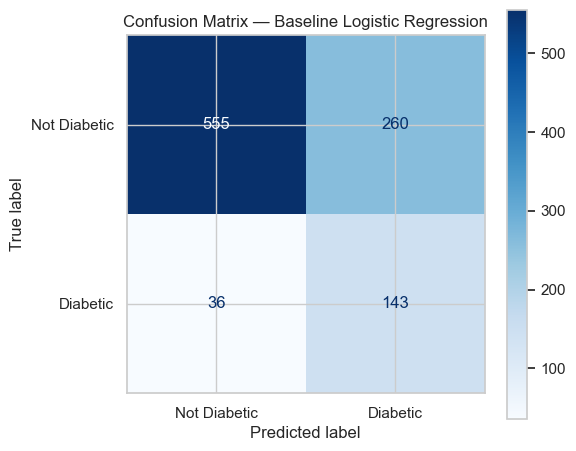

In [40]:
# Step 5 — Evaluate the model
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# AUC-ROC score
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc:.3f}")
print()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Not Diabetic', 'Diabetic']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Diabetic', 'Diabetic'],
    cmap='Blues',
    ax=ax)
ax.set_title('Confusion Matrix — Baseline Logistic Regression', fontsize=12)
plt.tight_layout()
plt.show()

### Baseline Model Results

| Metric | Score |
|--------|-------|
| AUC-ROC | 0.806 |
| Recall (diabetic) | 0.80 |
| Precision (diabetic) | 0.35 |
| Overall Accuracy | 0.70 |

The baseline logistic regression achieves an AUC-ROC of 0.806, which is 
a strong result for a baseline model. The model correctly identifies 80% 
of diabetic individuals (recall), which is the priority metric given the 
real-world cost of missing a diabetes diagnosis.

The lower precision (0.35) means the model generates false positives — 
flagging some non-diabetic people as at-risk. In a public health screening 
context this is acceptable, as a false positive leads to further testing 
rather than harm.

In Module 24, Random Forest and XGBoost models will be used to improve 
upon this baseline.

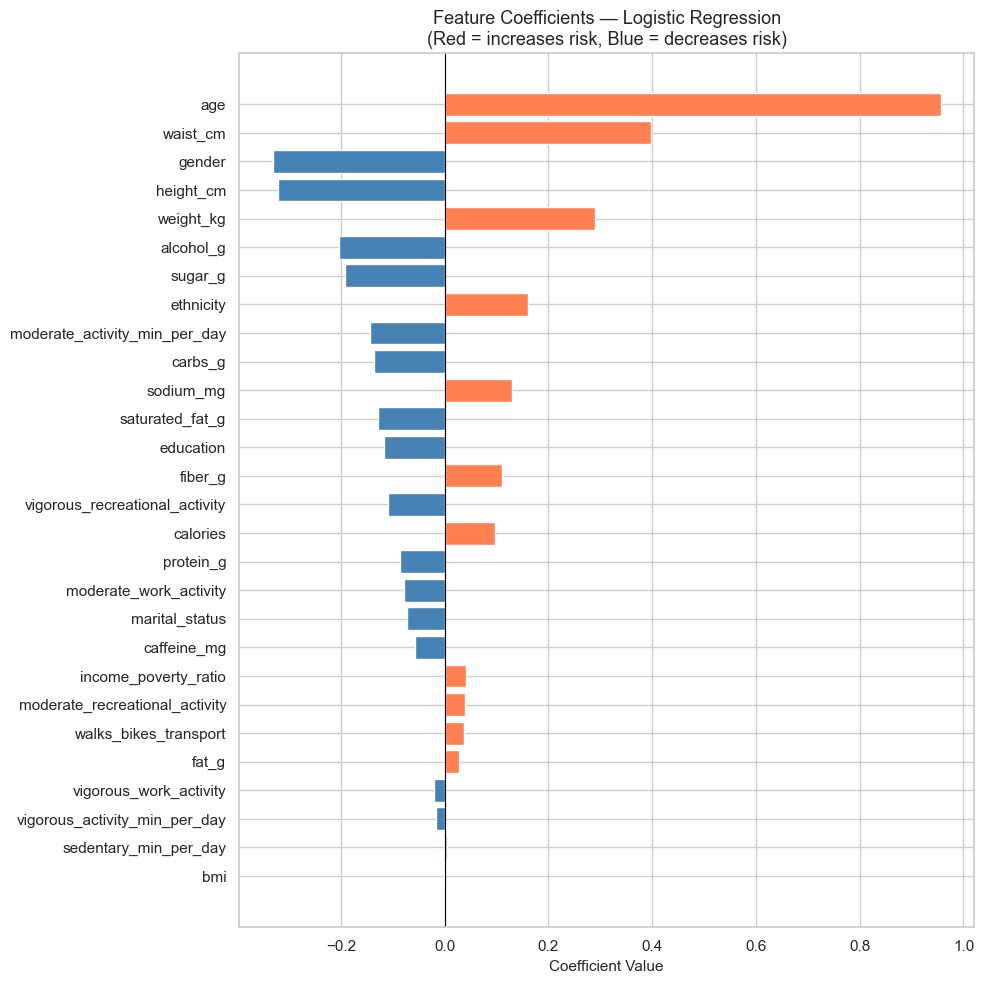

In [41]:
# Step 6 — Feature importance from logistic regression coefficients
importance = pd.DataFrame({
    'feature': features.columns,
    'coefficient': model.coef_[0]
})
importance['abs_coefficient'] = importance['coefficient'].abs()
importance = importance.sort_values('abs_coefficient', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['coral' if c > 0 else 'steelblue' for c in importance['coefficient']]
ax.barh(importance['feature'], importance['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients — Logistic Regression\n(Red = increases risk, Blue = decreases risk)', 
             fontsize=13)
ax.set_xlabel('Coefficient Value', fontsize=11)
plt.tight_layout()
plt.show()

### Feature Importance Summary
The logistic regression coefficients confirm our EDA findings:

- **Age** is the single strongest predictor of diabetes risk
- **Waist circumference** and **weight** are the strongest body composition predictors
- **Dietary variables** have modest coefficients, consistent with weak correlations found in EDA
- **Physical activity** shows a modest protective effect
- **BMI** shows near-zero coefficient due to multicollinearity with waist_cm and weight — 
  this will be addressed in the improved models in Module 24

These findings suggest that non-modifiable factors (age) and body composition 
(waist, weight) dominate diabetes risk, while lifestyle factors (diet, activity) 
play a supporting role that may be more important for intervention than prediction.